## Part 1: CPU Scheduling (FCFS)

In [4]:
# Get input from user
n = int(input("Enter number of processes: "))
processes = []

for i in range(n):
    print(f"\nProcess {i+1}:")
    arrival = int(input("Arrival Time: "))
    burst = int(input("Burst Time: "))
    processes.append({'id': i+1, 'at': arrival, 'bt': burst})

# Sort by arrival time
processes.sort(key=lambda x: x['at'])

current_time = 0
gantt_chart = "|"

for p in processes:
    # Handle CPU idle time
    if current_time < p['at']:
        idle_period = p['at'] - current_time
        gantt_chart += f" IDLE ({current_time}-{p['at']}) |"
        current_time = p['at']
    
    p['start'] = current_time
    p['finish'] = current_time + p['bt']
    p['tat'] = p['finish'] - p['at']
    p['wt'] = p['tat'] - p['bt']
    
    # Add to Gantt chart string
    gantt_chart += f" P{p['id']} ({p['start']}-{p['finish']}) |"
    current_time = p['finish']

# Calculate averages
avg_wt = sum(p['wt'] for p in processes) / n
avg_tat = sum(p['tat'] for p in processes) / n

# Display Results
print("\n" + "="*50)
print("ID\tArrival\tBurst\tWaiting\tTurnaround")
print("-" * 50)
for p in processes:
    print(f"P{p['id']}\t{p['at']}\t{p['bt']}\t{p['wt']}\t{p['tat']}")

print("\n--- Visual Gantt Chart ---")
print(gantt_chart)

print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")




Process 1:

Process 2:

Process 3:

Process 4:

ID	Arrival	Burst	Waiting	Turnaround
--------------------------------------------------
P1	0	7	0	7
P2	2	5	5	10
P3	4	15	8	23
P4	8	7	19	26

--- Visual Gantt Chart ---
| P1 (0-7) | P2 (7-12) | P3 (12-27) | P4 (27-34) |

Average Waiting Time: 8.00
Average Turnaround Time: 16.50


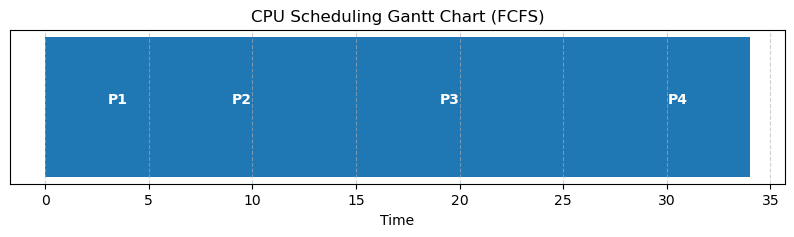

In [5]:
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Plotting each process as a bar
for p in processes:
    # ax.broken_barh takes [(start_position, width)]
    ax.broken_barh([(p['start'], p['bt'])], (10, 9), facecolors=('tab:blue'))
    # Add process ID text in the middle of the bar
    ax.text(p['start'] + p['bt']/2, 15, f"P{p['id']}", 
            ha='center', va='center', color='white', fontweight='bold')

# Formatting the chart
ax.set_yticks([]) # Hide y-axis
ax.set_xlabel('Time')
ax.set_title('CPU Scheduling Gantt Chart (FCFS)')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)

plt.show()

## Part 2: Memory Allocation (First Fit) 

In [7]:
# Get memory blocks from user
b_count = int(input("Enter number of memory blocks: "))
blocks = []
for i in range(b_count):
    size = int(input(f"Block {i+1} size: "))
    # Store block ID, current size, and original size for fragmentation
    blocks.append({'id': i+1, 'size': size, 'original': size})

# Get processes from user
p_count = int(input("\nEnter number of processes: "))
mem_processes = []
for i in range(p_count):
    size = int(input(f"Process {i+1} size: "))
    mem_processes.append({'id': i+1, 'size': size, 'block_id': "Not Allocated"})

# First Fit Logic
for p in mem_processes:
    for b in blocks:
        if b['size'] >= p['size']:
            p['block_id'] = b['id'] # Assign process to block
            b['size'] -= p['size']  # Calculate remaining space (Internal Fragmentation)
            break # Process is allocated, move to next one

# Display Results
print("\n" + "="*40)
print("Process ID\tSize\tAllocated Block")
print("-" * 40)
for p in mem_processes:
    print(f"P{p['id']}\t\t{p['size']}\t{p['block_id']}")

print("\n--- Memory Status (Internal Fragmentation) ---")
for b in blocks:
    print(f"Block {b['id']} (Original: {b['original']}): {b['size']} units left")


Process ID	Size	Allocated Block
----------------------------------------
P1		35	1
P2		50	2
P3		60	2
P4		150	3
P5		70	4

--- Memory Status (Internal Fragmentation) ---
Block 1 (Original: 50): 15 units left
Block 2 (Original: 120): 10 units left
Block 3 (Original: 150): 0 units left
Block 4 (Original: 200): 130 units left
Block 5 (Original: 300): 300 units left


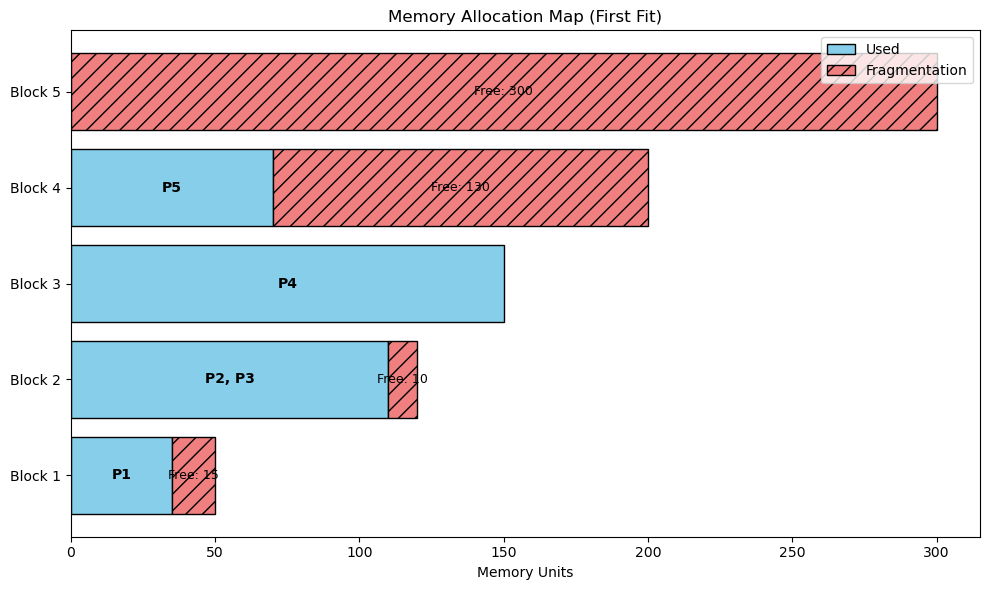

In [14]:
#  Visualization for Memory Allocation (First Fit) 

fig, ax = plt.subplots(figsize=(10, 6))

# We will draw blocks as horizontal bars
for i, b in enumerate(blocks):
    # Total size of the block
    original_size = b['original']
    remaining_size = b['size']
    used_size = original_size - remaining_size
    
    #  Draw the used part (Process)
    if used_size > 0:
        ax.barh(f"Block {b['id']}", used_size, color='skyblue', edgecolor='black', label='Used' if i==0 else "")
        # Label which process is inside
        # We find processes assigned to this block
        p_in_block = [p['id'] for p in mem_processes if p['block_id'] == b['id']]
        if p_in_block:
            p_text = ", ".join([f"P{pid}" for pid in p_in_block])
            ax.text(used_size/2, i, p_text, ha='center', va='center', fontweight='bold')
    
    # 2. Draw the remaining part (Internal Fragmentation)
    if remaining_size > 0:
        ax.barh(f"Block {b['id']}", remaining_size, left=used_size, color='lightcoral', 
                edgecolor='black', hatch='//', label='Fragmentation' if i==0 else "")
        ax.text(used_size + remaining_size/2, i, f"Free: {remaining_size}", 
                ha='center', va='center', fontsize=9)

# Formatting
ax.set_xlabel('Memory Units')
ax.set_title('Memory Allocation Map (First Fit)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Part 3: Page Replacement (FIFO) 

In [10]:
# Get dynamic input from user
capacity = int(input("\nEnter number of frames in RAM: "))
pages = list(map(int, input("Enter page reference string (numbers separated by space): ").split()))

print(f"\nUser Input Pages: {pages}")

# Setup variables
memory = []
page_faults = 0
history = []

print("\nStep-by-step Execution:")
print("Incoming | Memory Frame Status | Result")
print("-" * 45)

# FIFO Logic
for page in pages:
    if page not in memory:
        # If memory is full, remove the oldest page (index 0)
        if len(memory) == capacity:
            memory.pop(0)
        
        # Add new page and count as a fault
        memory.append(page)
        page_faults += 1
        status = "MISS (Fault)"
    else:
        status = "HIT"
        
    history.append(list(memory))
    # Display step-by-step
    print(f"   {page}     | {memory} | {status}")

# Final Result
print("-" * 45)
print(f"Total Page Faults: {page_faults}")


User Input Pages: [1, 2, 4, 7, 4, 5, 2, 3, 1, 5, 7, 6, 4, 3, 5, 6, 6, 3, 1, 2, 4, 5, 3, 2, 1]

Step-by-step Execution:
Incoming | Memory Frame Status | Result
---------------------------------------------
   1     | [1] | MISS (Fault)
   2     | [1, 2] | MISS (Fault)
   4     | [1, 2, 4] | MISS (Fault)
   7     | [1, 2, 4, 7] | MISS (Fault)
   4     | [1, 2, 4, 7] | HIT
   5     | [2, 4, 7, 5] | MISS (Fault)
   2     | [2, 4, 7, 5] | HIT
   3     | [4, 7, 5, 3] | MISS (Fault)
   1     | [7, 5, 3, 1] | MISS (Fault)
   5     | [7, 5, 3, 1] | HIT
   7     | [7, 5, 3, 1] | HIT
   6     | [5, 3, 1, 6] | MISS (Fault)
   4     | [3, 1, 6, 4] | MISS (Fault)
   3     | [3, 1, 6, 4] | HIT
   5     | [1, 6, 4, 5] | MISS (Fault)
   6     | [1, 6, 4, 5] | HIT
   6     | [1, 6, 4, 5] | HIT
   3     | [6, 4, 5, 3] | MISS (Fault)
   1     | [4, 5, 3, 1] | MISS (Fault)
   2     | [5, 3, 1, 2] | MISS (Fault)
   4     | [3, 1, 2, 4] | MISS (Fault)
   5     | [1, 2, 4, 5] | MISS (Fault)
   3     | [2, 4,

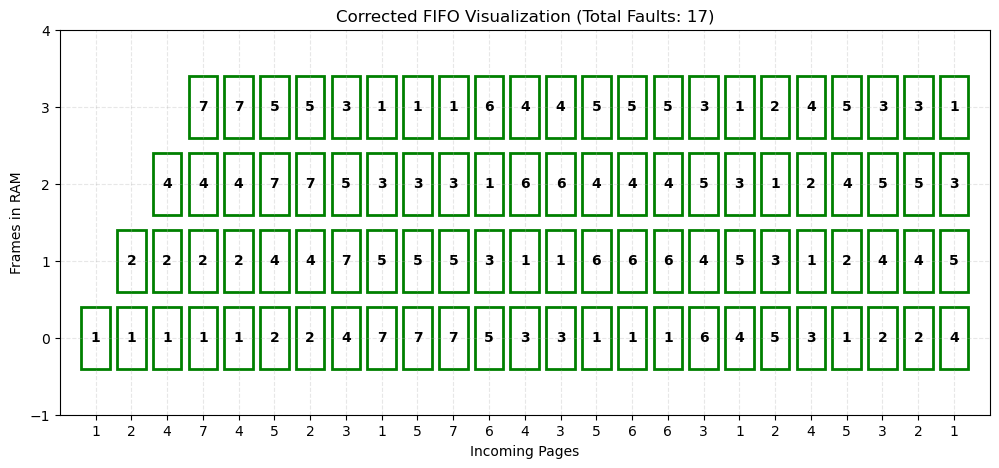

In [13]:
# Visualization Section
fig, ax = plt.subplots(figsize=(12, 5))

for i, step in enumerate(history):
    for j, p_val in enumerate(step):
        if p_val is not None:
            # Draw page number
            ax.text(i, j, str(p_val), ha='center', va='center', fontweight='bold')
            # Draw frame box
            rect = plt.Rectangle((i-0.4, j-0.4), 0.8, 0.8, fill=False, edgecolor='green', linewidth=2)
            ax.add_patch(rect)

# Formatting the plot
ax.set_ylim(-1, capacity)
ax.set_xlim(-1, len(pages))
ax.set_xticks(range(len(pages)))
ax.set_xticklabels(pages)
ax.set_xlabel("Incoming Pages")
ax.set_ylabel("Frames in RAM")
ax.set_title(f"Corrected FIFO Visualization (Total Faults: {page_faults})")
ax.grid(True, linestyle='--', alpha=0.3)

plt.show()